# 3D Hetero SSR Notebook Workflow

This notebook turns the `3d_hetero_ssr_default` benchmark into an inspectable workflow instead of a single shell command.

The structure is deliberate:
- first define the case from the config side in editable sections,
- then run the existing PETSc solver in parallel while streaming rank-0 progress back into the notebook,
- then inspect the saved artifacts: convergence curves, timings, solver PNGs, and PyVista views built from the exported VTU.

This notebook assumes you are using the project venv as the notebook kernel and that the visualization extras are installed.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt

candidate = Path("benchmarks/3d_hetero_ssr_default").resolve()
CASE_DIR = candidate if candidate.exists() else Path.cwd().resolve()
if str(CASE_DIR) not in sys.path:
    sys.path.insert(0, str(CASE_DIR))

import notebook_support as _nb
nb = importlib.reload(_nb)

ROOT = nb.ROOT
CASE_TOML = nb.DEFAULT_CASE_TOML

print(f"Repo root: {ROOT}")
print(f"Benchmark folder: {CASE_DIR}")
print(f"Base case config: {CASE_TOML}")


Repo root: /home/beremi/repos/slope_stability-1
Benchmark folder: /home/beremi/repos/slope_stability-1/benchmarks/3d_hetero_ssr_default
Base case config: /home/beremi/repos/slope_stability-1/benchmarks/3d_hetero_ssr_default/case.toml


## Load The Baseline Benchmark Config

Start from the benchmark TOML instead of rebuilding the case by hand.

That keeps the notebook aligned with the command-line benchmark while still letting us override individual sections in later cells.

In [2]:
sections = nb.load_case_sections(CASE_TOML)
sections

{'problem': {'name': '3d_hetero_ssr_default',
  'case': '3d_hetero_ssr',
  'analysis': 'ssr',
  'dimension': 3,
  'variant': 'hetero',
  'elem_type': 'P2',
  'davis_type': 'B',
  'seepage': False,
  'mesh_path': '../../meshes/3d_hetero_ssr/SSR_hetero_ada_L1.msh'},
 'execution': {'node_ordering': 'block_metis',
  'mpi_distribute_by_nodes': True,
  'constitutive_mode': 'overlap'},
 'continuation': {'method': 'indirect',
  'lambda_init': 1.0,
  'd_lambda_init': 0.1,
  'd_lambda_min': 0.001,
  'd_lambda_diff_scaled_min': 0.001,
  'omega_max': 12000000.0,
  'step_max': 100},
 'newton': {'it_max': 200, 'it_damp_max': 10, 'tol': 0.0001, 'r_min': 0.0001},
 'linear_solver': {'solver_type': 'PETSC_MATLAB_DFGMRES_HYPRE_NULLSPACE',
  'tolerance': 0.1,
  'max_iterations': 100,
  'deflation_basis_tolerance': 0.001,
  'threads': 16,
  'print_level': 0,
  'use_as_preconditioner': True,
  'compiled_outer': False,
  'recycle_preconditioner': True,
  'pc_hypre_coarsen_type': 'HMIS',
  'pc_hypre_interp_ty

## Problem Definition

This section defines the physical case we want to solve: the mesh, element order, analysis type, and the boundary-label convention expected by the 3D heterogeneous SSR runner.

For this benchmark the material table is resolved from the mesh family definition, so we do not need to inline `[[materials]]` here.

In [3]:
problem = sections["problem"]
problem["mesh_path"] = "../../meshes/3d_hetero_ssr/SSR_hetero_ada_L1.msh"
problem["analysis"] = "ssr"
problem["elem_type"] = "P2"
problem["mesh_boundary_type"] = 0
problem

{'name': '3d_hetero_ssr_default',
 'case': '3d_hetero_ssr',
 'analysis': 'ssr',
 'dimension': 3,
 'variant': 'hetero',
 'elem_type': 'P2',
 'davis_type': 'B',
 'seepage': False,
 'mesh_path': '../../meshes/3d_hetero_ssr/SSR_hetero_ada_L1.msh',
 'mesh_boundary_type': 0}

## Execution And Distribution Choices

This section controls how the mesh and the constitutive work are arranged across MPI ranks.

- `block_metis` is the main parallel ordering choice for distributed runs.
- `mpi_distribute_by_nodes = true` keeps the lightweight distributed assembly path enabled.
- `constitutive_mode = "overlap"` matches the current default benchmark path.

In [4]:
execution = sections["execution"]
execution["node_ordering"] = "block_metis"
execution["mpi_distribute_by_nodes"] = True
execution["constitutive_mode"] = "overlap"
execution

{'node_ordering': 'block_metis',
 'mpi_distribute_by_nodes': True,
 'constitutive_mode': 'overlap'}

## Continuation And Newton Controls

The continuation parameters decide how aggressively the solver advances the SSR path, while the Newton block controls the nonlinear solve at each attempted point.

Use this cell when you want to shorten notebook runs, make the solve more conservative, or push farther along the path.

In [5]:
continuation = sections["continuation"]
newton = sections["newton"]

continuation["step_max"] = 12
continuation["omega_max"] = 1.2e7
newton["it_max"] = 200
newton["tol"] = 1e-4

{"continuation": continuation, "newton": newton}

{'continuation': {'method': 'indirect',
  'lambda_init': 1.0,
  'd_lambda_init': 0.1,
  'd_lambda_min': 0.001,
  'd_lambda_diff_scaled_min': 0.001,
  'omega_max': 12000000.0,
  'step_max': 12},
 'newton': {'it_max': 200, 'it_damp_max': 10, 'tol': 0.0001, 'r_min': 0.0001}}

## Linear Solver And Export Policy

The linear-solver block tunes the PETSc side of the run.

The export block matters for the notebook because it ensures we save everything needed for post-processing:
- `run_info.json` and `petsc_run.npz` from the main run,
- `continuation_history.json` for structured progress/timing history,
- `final_solution.vtu` for PyVista.

In [6]:
linear_solver = sections["linear_solver"]
export = sections["export"]
export.update(nb.default_export_section())

linear_solver["threads"] = 16
linear_solver["print_level"] = 0
export["write_custom_debug_bundle"] = True
export["write_history_json"] = True
export["write_solution_vtu"] = True
export["solution_name"] = "final_solution.vtu"

{"linear_solver": linear_solver, "export": export}

{'linear_solver': {'solver_type': 'PETSC_MATLAB_DFGMRES_HYPRE_NULLSPACE',
  'tolerance': 0.1,
  'max_iterations': 100,
  'deflation_basis_tolerance': 0.001,
  'threads': 16,
  'print_level': 0,
  'use_as_preconditioner': True,
  'compiled_outer': False,
  'recycle_preconditioner': True,
  'pc_hypre_coarsen_type': 'HMIS',
  'pc_hypre_interp_type': 'ext+i'},
 'export': {'write_custom_debug_bundle': True,
  'write_history_json': True,
  'write_solution_vtu': True,
  'custom_debug_name': 'run_debug.h5',
  'history_name': 'continuation_history.json',
  'solution_name': 'final_solution.vtu'}}

## Notebook-Only Run Controls

These values are not part of the solver config itself. They control how this notebook launches the job and where it stores the artifacts.

Use `MPI_RANKS` to switch between a quick local smoke test and a heavier parallel run.

In [7]:
MPI_RANKS = 8
RUN_LABEL = "pyvista_workflow"
OUT_DIR = ROOT / "artifacts" / "notebooks" / "3d_hetero_ssr_default" / RUN_LABEL
GENERATED_CONFIG = CASE_DIR / "notebook_case.generated.toml"

config_preview = nb.render_case_toml(sections)
print(config_preview)

[problem]
name = "3d_hetero_ssr_default"
case = "3d_hetero_ssr"
analysis = "ssr"
dimension = 3
variant = "hetero"
elem_type = "P2"
davis_type = "B"
seepage = false
mesh_path = "../../meshes/3d_hetero_ssr/SSR_hetero_ada_L1.msh"
mesh_boundary_type = 0

[execution]
node_ordering = "block_metis"
mpi_distribute_by_nodes = true
constitutive_mode = "overlap"

[continuation]
method = "indirect"
lambda_init = 1.0
d_lambda_init = 0.1
d_lambda_min = 0.001
d_lambda_diff_scaled_min = 0.001
omega_max = 12000000.0
step_max = 12

[newton]
it_max = 200
it_damp_max = 10
tol = 0.0001
r_min = 0.0001

[linear_solver]
solver_type = "PETSC_MATLAB_DFGMRES_HYPRE_NULLSPACE"
tolerance = 0.1
max_iterations = 100
deflation_basis_tolerance = 0.001
threads = 16
print_level = 0
use_as_preconditioner = true
compiled_outer = false
recycle_preconditioner = true
pc_hypre_coarsen_type = "HMIS"
pc_hypre_interp_type = "ext+i"

[export]
write_custom_debug_bundle = true
write_history_json = true
write_solution_vtu = true
cust

## Write The Config And Run In Parallel

This cell does the real work.

It writes a generated TOML next to the notebook, launches the normal config runner through `mpiexec`, streams rank-0 progress into the notebook, and returns a summary dictionary when the run is finished.

The saved outputs land in `OUT_DIR` and are reused by the later plotting cells.

In [8]:
nb.write_case_toml(sections, GENERATED_CONFIG)
result = nb.run_parallel_case(
    config_path=GENERATED_CONFIG,
    out_dir=OUT_DIR,
    mpi_ranks=MPI_RANKS,
)


Launching solver:
  /usr/bin/mpiexec -n 8 /home/beremi/repos/slope_stability-1/.venv/bin/python -m slope_stability.cli.run_case_from_config /home/beremi/repos/slope_stability-1/benchmarks/3d_hetero_ssr_default/notebook_case.generated.toml --out_dir /home/beremi/repos/slope_stability-1/artifacts/notebooks/3d_hetero_ssr_default/pyvista_workflow
Output directory: /home/beremi/repos/slope_stability-1/artifacts/notebooks/3d_hetero_ssr_default/pyvista_workflow
[solver] 
[solver] 
[solver] 
[solver] 
[solver] 
[solver] 
[solver] 
[solver] 
[rank0-progress] init_complete accepted_steps=2 lambda_hist=[1.0, 1.1] omega_hist=[6214942.103875942, 6229234.524843297]
[rank0-progress] attempt_complete target_step=3 attempt_in_step=1 success=True lambda_before=1.1 lambda_after=1.1598630692435266 newton_iterations=6 linear_iterations=54
[rank0-progress] step_accepted accepted_step=3 lambda=1.1598630692435266 omega=6243526.945810652 u_max=0.8299611147855289 wall=3.070438866969198
[rank0-progress] attempt_

In [9]:
artifacts = nb.load_run_artifacts(OUT_DIR)
result

{'out_dir': '/home/beremi/repos/slope_stability-1/artifacts/notebooks/3d_hetero_ssr_default/pyvista_workflow',
 'run_info_path': '/home/beremi/repos/slope_stability-1/artifacts/notebooks/3d_hetero_ssr_default/pyvista_workflow/data/run_info.json',
 'npz_path': '/home/beremi/repos/slope_stability-1/artifacts/notebooks/3d_hetero_ssr_default/pyvista_workflow/data/petsc_run.npz',
 'vtu_path': '/home/beremi/repos/slope_stability-1/artifacts/notebooks/3d_hetero_ssr_default/pyvista_workflow/exports/final_solution.vtu',
 'step_count': 12,
 'lambda_last': 1.6568602600672142,
 'omega_last': 8244465.881240404,
 'runtime_seconds': 80.97327900095843}

## Inspect The Saved Run Summary

This cell prints the high-level metadata written by the solver and then lists the files generated for the run.

That makes it easy to see what is available before plotting anything.

In [10]:
nb.show_run_summary(artifacts)
print("")
print("Saved files:")
for path in sorted(OUT_DIR.rglob("*")):
    if path.is_file():
        print(" ", path.relative_to(ROOT))

{
  "timestamp": "2026-03-14T22:46:39",
  "python_version": "petsc driver",
  "runtime_seconds": 80.97327900095843,
  "mpi_size": 8,
  "mesh_nodes": 27605,
  "mesh_elements": 18419,
  "unknowns": 80362,
  "analysis": "ssr",
  "solver_type": "PETSC_MATLAB_DFGMRES_HYPRE_NULLSPACE",
  "step_count": 12
}

{
  "mesh_file": "/home/beremi/repos/slope_stability-1/meshes/3d_hetero_ssr/SSR_hetero_ada_L1.msh",
  "coord_shape": [
    3,
    27605
  ],
  "elem_shape": [
    10,
    18419
  ],
  "surf_shape": [
    6,
    6325
  ]
}

{
  "constitutive": {
    "reduction": 1.2075529233552516,
    "stress": 3.7176588363945484,
    "stress_tangent": 1.774177445564419,
    "build_F": 3.7837796669919044,
    "build_F_K_tangent": 0.0,
    "build_tangent_local": 6.678009467665106,
    "local_strain": 3.547215182799846,
    "local_constitutive": 1.9303802514914423,
    "local_constitutive_comm": 0.0,
    "local_force_assembly": 3.7831062441691756,
    "local_force_gather": 0.0,
    "potential": 0.0
  },
  "

## Convergence, Iteration, And Timing Graphs

These plots are built from the saved `petsc_run.npz` and `continuation_history.json` exports rather than from in-memory solver state.

That is important because it means the notebook is inspecting exactly what was persisted by the run.

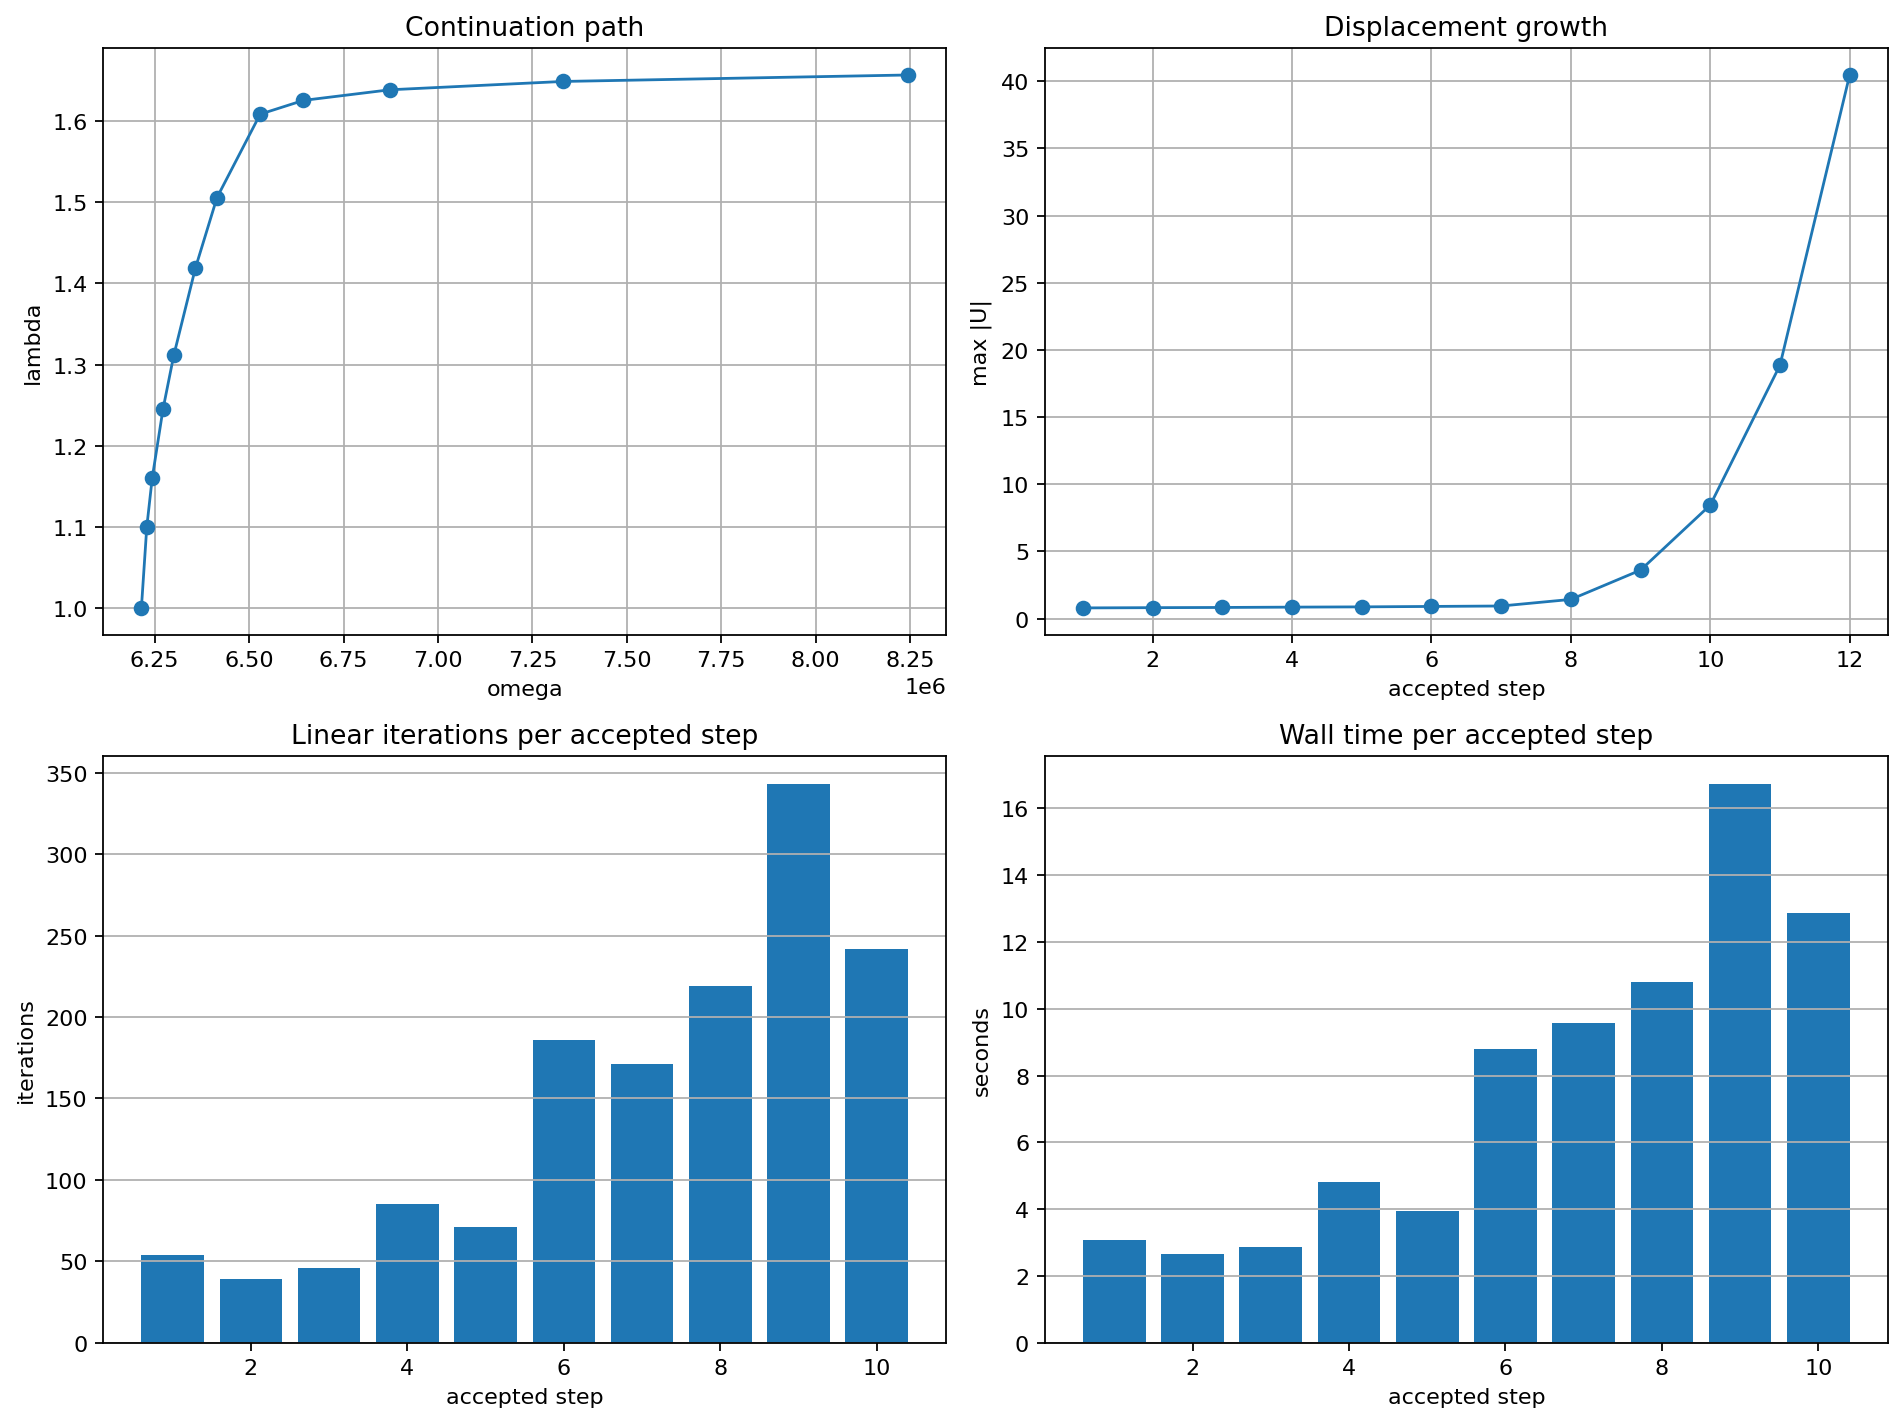

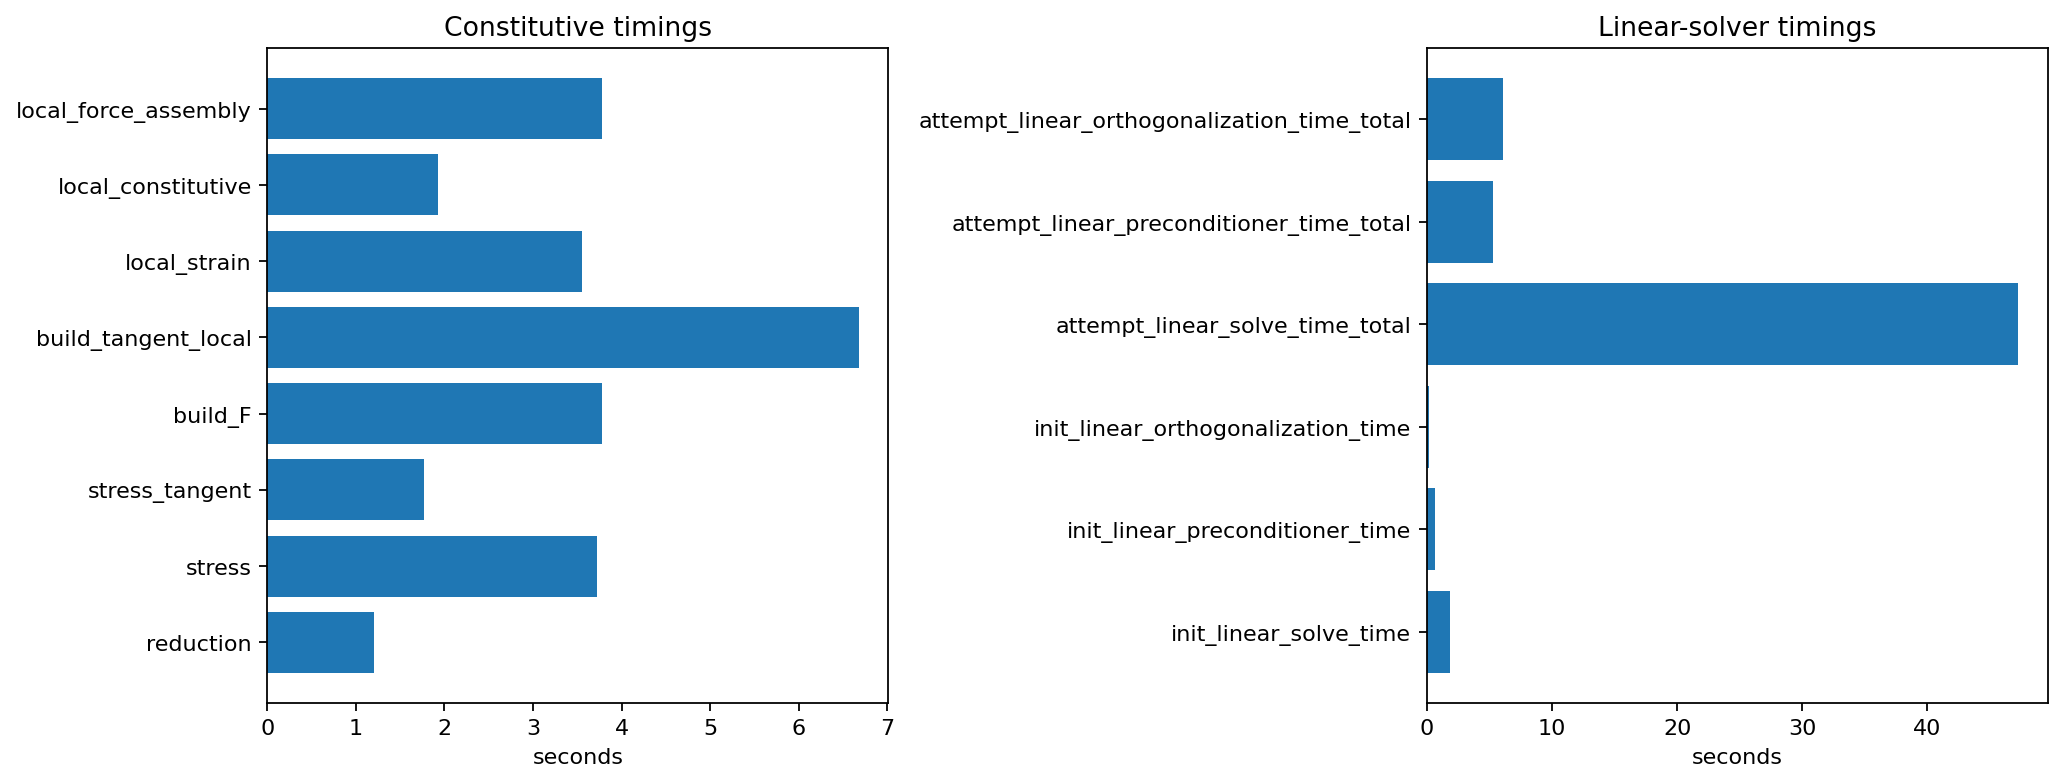

In [11]:
_ = nb.plot_convergence_dashboard(artifacts)
plt.show()
_ = nb.plot_timing_breakdown(artifacts)
plt.show()

## Static Solver Figures Saved By The Benchmark Runner

The benchmark already writes a few static PNGs on rank 0. This cell displays those exact images so you can compare the notebook views against the original runner outputs.

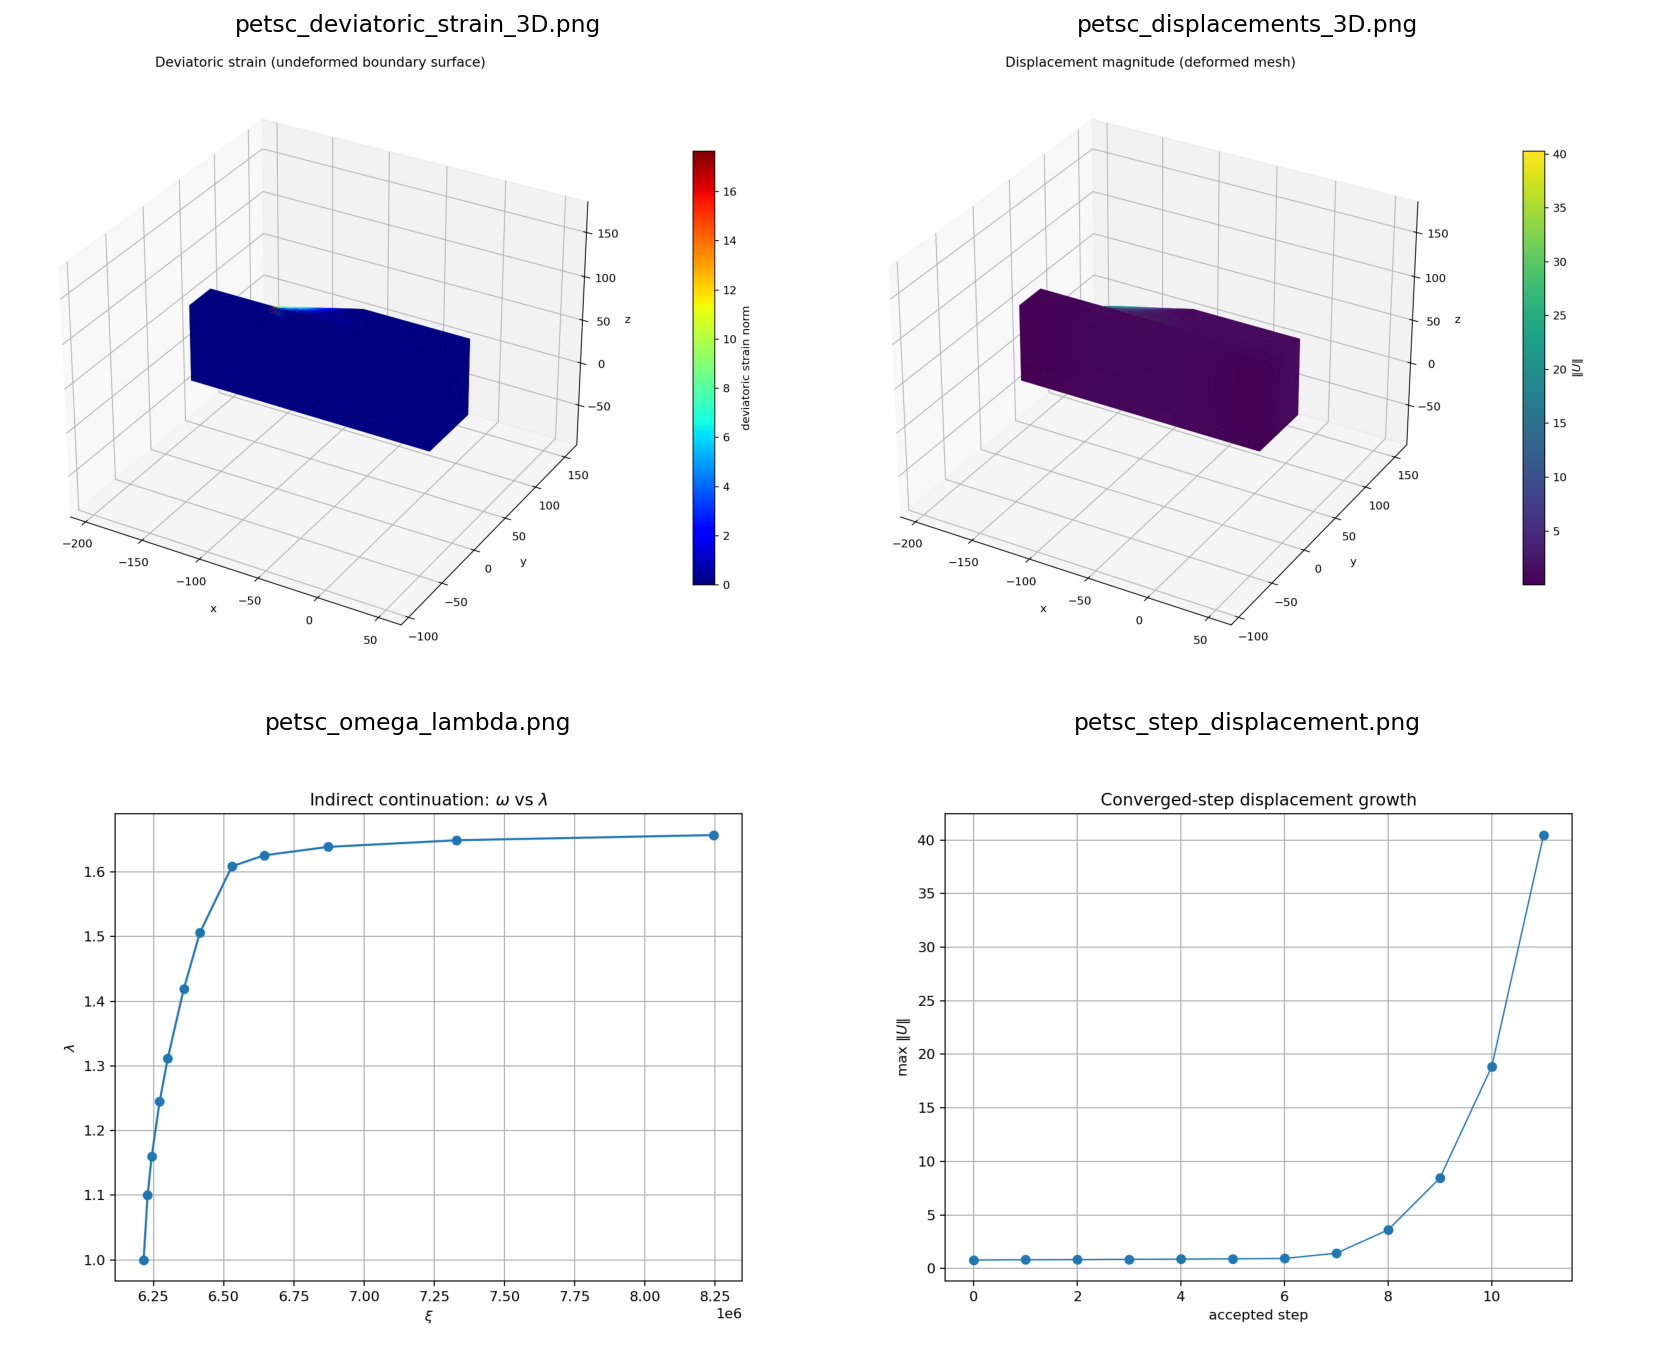

In [12]:
_ = nb.display_saved_solver_figures(artifacts)
plt.show()

## MATLAB-Style Strain Surface

This rebuilds the final deviatoric strain from the FE strain operator and colors the undeformed boundary surface, which is much closer to the MATLAB visual convention than the earlier centroid-scatter proxy.

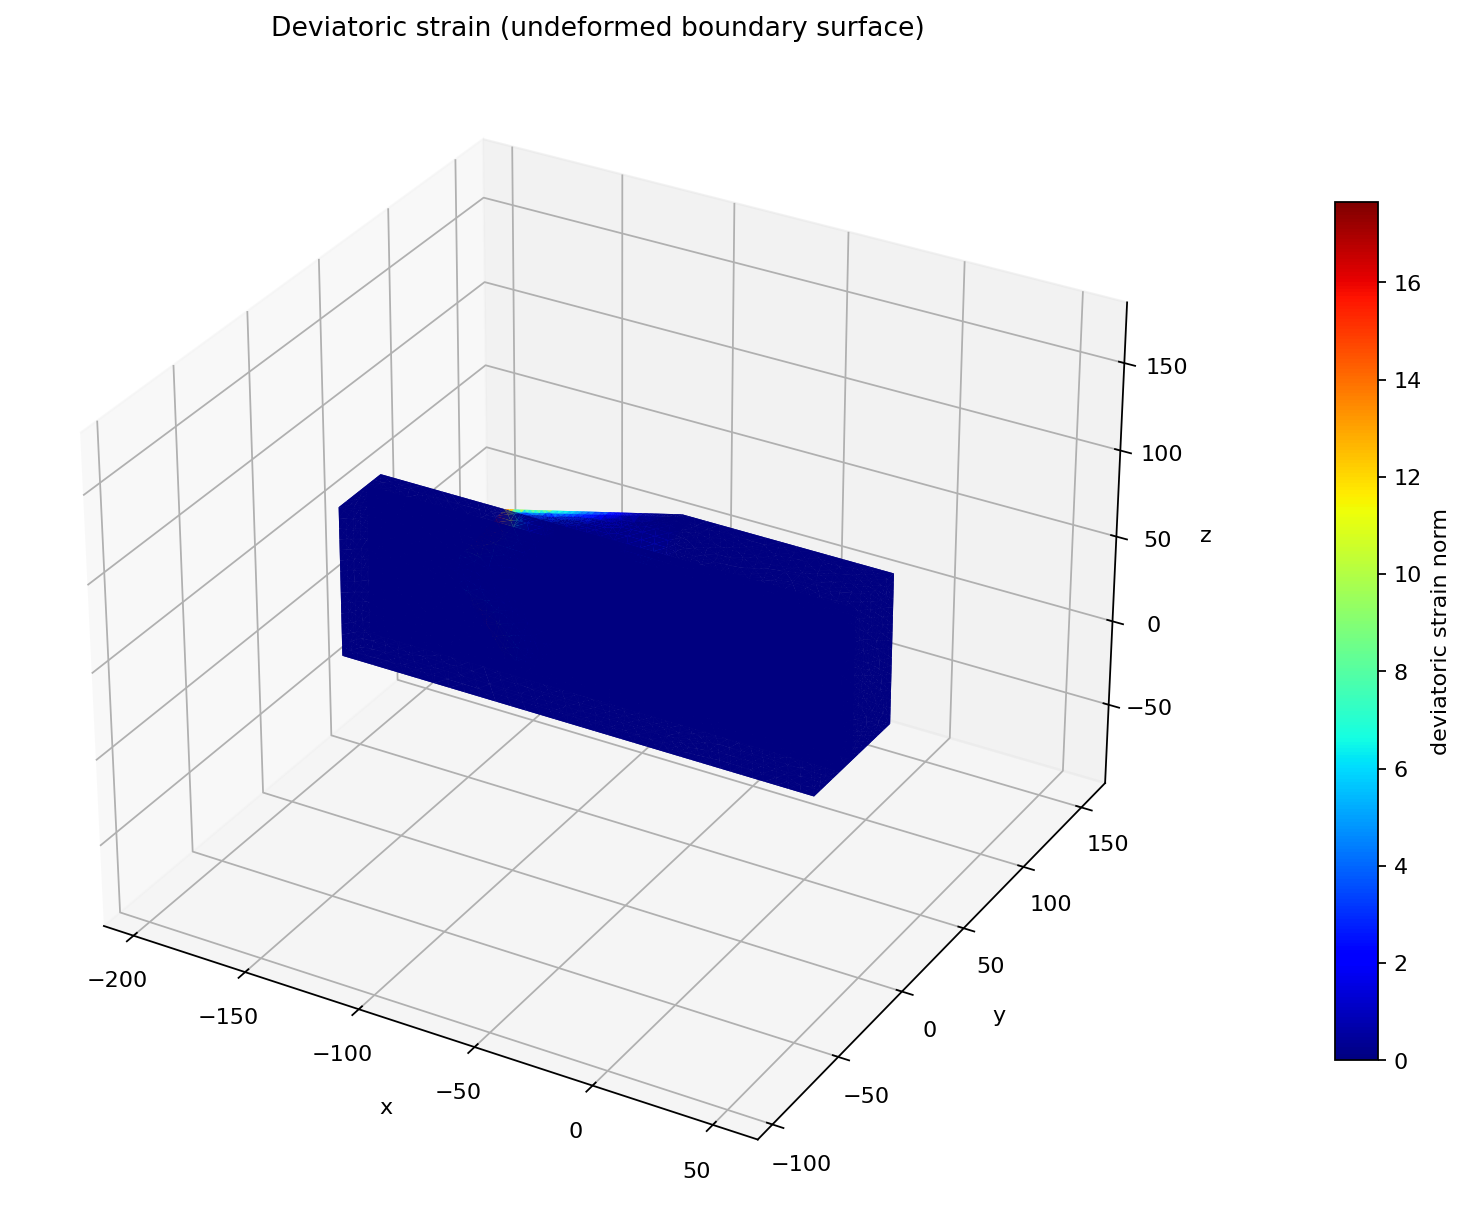

In [13]:
_ = nb.plot_matlab_style_strain_surface(artifacts, GENERATED_CONFIG)
plt.show()

## Prepare PyVista

Now switch to the exported VTU so we can build interactive 3D views without reconstructing the mesh manually.

This notebook intentionally prefers the `client` backend before full `trame` server rendering. That choice is more robust on machines where VTK emits GLX or NVIDIA driver warnings, because the interactive scene is rendered in the browser instead of relying on server-side OpenGL.

The next cell also starts the Trame server explicitly with `await`, which avoids the PyVista fallback warning about `nest_asyncio2` and makes the interactive views deterministic.

In [14]:
_trame_server = await nb.ensure_trame_server()
backend = nb.configure_pyvista_backend(("server", "client", "html", "static"))
base_grid = nb.load_solution_grid(artifacts)
strain_visuals = nb.prepare_deviatoric_strain_visuals(artifacts, GENERATED_CONFIG, grid=base_grid)
grid = strain_visuals.volume_grid
strain_surface = strain_visuals.surface_grid

print("PyVista notebook backend:", backend)
print(grid)
print("Point data:", list(grid.point_data.keys()))
print("Cell data:", list(grid.cell_data.keys()))
print("Surface cell data:", list(strain_surface.cell_data.keys()))



PyVista notebook backend: server
UnstructuredGrid (0x7fc336ca5780)
  N Cells:    18419
  N Points:   27605
  X Bounds:   -1.750e+02, 3.000e+01
  Y Bounds:   0.000e+00, 6.000e+01
  Z Bounds:   0.000e+00, 8.660e+01
  N Arrays:   7
Point data: ['displacement', 'displacement_magnitude', 'deviatoric_strain_point']
Cell data: ['material_id', 'deviatoric_strain']
Surface cell data: ['material_id', 'vtkOriginalCellIds', 'deviatoric_strain']


## Static Deviatoric-Strain Slices

These are static mid-plane slices of the final **deviatoric strain** field, one figure per principal direction. The slice geometry comes from PyVista, but the result is shown as fixed figures so the presentation is stable and MATLAB-like.

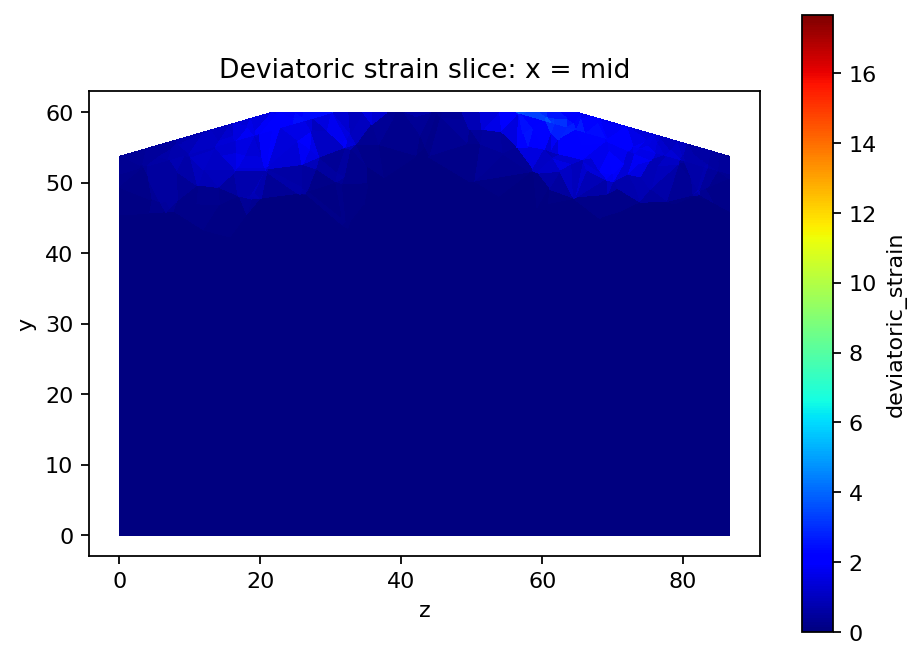

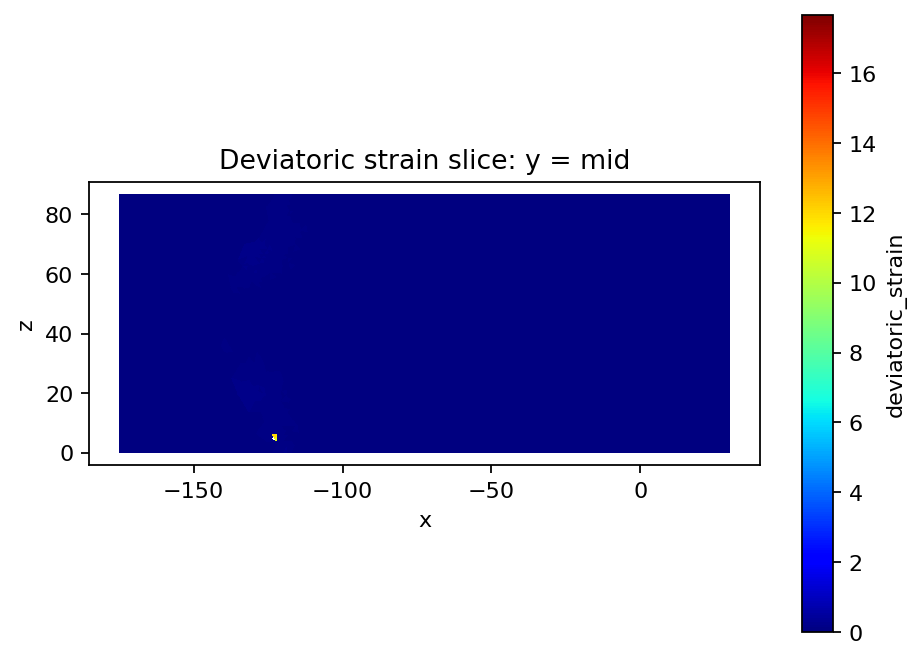

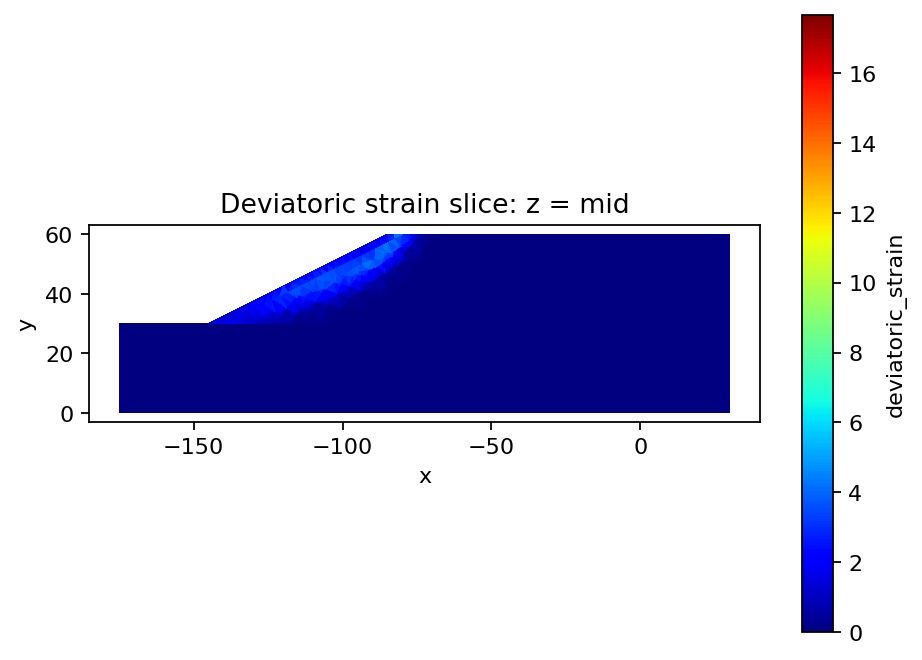

In [15]:
_ = nb.plot_static_deviatoric_slices(grid, scalar="deviatoric_strain")
plt.show()

## Interactive Deviatoric-Strain Y Slice

This view keeps a single slice normal to the `y` axis and gives you a notebook slider above the PyVista scene. 
Move that slider to inspect the deviatoric strain at a specific `y` level while still rotating and zooming the PyVista view below.


In [16]:
y_slice_widget = nb.build_y_slice_notebook_widget(
    grid,
    scalar="deviatoric_strain",
    backend=backend,
)
y_slice_widget


## Interactive Deviatoric-Strain X Slice

This view keeps a single slice normal to the `x` axis and gives you the same interactive slider-driven inspection as the `y` slice. Use it when you want to inspect how the deviatoric strain evolves across the slope width.


In [17]:
x_slice_widget = nb.build_x_slice_notebook_widget(
    grid,
    scalar="deviatoric_strain",
    backend=backend,
)
x_slice_widget


## Interactive Deviatoric-Strain Z Slice

This view keeps a single slice normal to the `z` axis. It is useful for checking how the strain field changes with elevation while keeping the same interactive PyVista controls and scalar mapping.


In [18]:
z_slice_widget = nb.build_z_slice_notebook_widget(
    grid,
    scalar="deviatoric_strain",
    backend=backend,
)
z_slice_widget


## Interactive Deformed Shape

This is the interactive PyVista deformation view, warped by the exported displacement vector and colored by displacement magnitude.

In [19]:
deformed_widget = nb.build_deformed_notebook_widget(
    grid,
    scale_factor=1.0,
    backend=backend,
)
deformed_widget


## Interactive Deviatoric-Strain Surface

This is the PyVista 3D deviatoric-strain view on the **undeformed boundary surface**. It follows the same visual idea as the MATLAB-style strain plot, but remains fully interactive in the notebook.

In [20]:
strain_surface_widget = nb.build_deviatoric_surface_notebook_widget(
    strain_surface,
    scalar="deviatoric_strain",
    backend=backend,
)
strain_surface_widget
